In [1]:
%matplotlib inline
import numpy as np
import xarray as xr
from datetime import datetime, timedelta
from matplotlib import pyplot as plt, rc,colors
import os
import netCDF4 as nc
import pandas as pd

In [2]:
M_path = '/home/jvalenti/MOAD/'
coords = xr.open_dataset(M_path+'grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)
mask = xr.open_dataset(M_path+'grid2/mesh_mask202108_TDV.nc')
lon = coords.nav_lon
x= np.linspace(0,lon.shape[1],lon.shape[1])
y = np.linspace(0,lon.shape[0],lon.shape[0])
X,Y = np.meshgrid(x,y)

In [3]:
jjii = xr.open_dataset('~/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

In [4]:
def make_filename(path_run,start,day, var='prod_T', res='d'):
    """Construct path prefix for local SHEM results given date object and paths dict
    """
    date  =  (start + timedelta(days=day))
    folder = date.strftime("%d%b%y").lower()
    prefix = os.path.join(path_run, f'{folder}/')
    fname = []
    for file in os.listdir(prefix):
        if (var in file) and ('_1'+res) in file:
            fname.append(file)
    if len(fname)>1:
        print('more than one file found') 
    
    return os.path.join(f'{folder}/', fname[0])

In [8]:
df = pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/biol_budget_2023-2025_2.csv', index_col=0, parse_dates=True)
df.index = pd.DatetimeIndex(df.index, freq="D")

df_plot = df

df = pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/biol_budget_2023-2025_202111.csv', index_col=0, parse_dates=True)
df.index = pd.DatetimeIndex(df.index, freq="D")
df_plot2 = df

df = pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/biol_budget_2023-2025_202606.csv', index_col=0, parse_dates=True)
df.index = pd.DatetimeIndex(df.index, freq="D")
df_plot3 = df

In [9]:
difference_fraction = (df_plot-df_plot2).div(df_plot2.sum(axis=1),axis=0)
difference_fraction['HBac']=df_plot['HBac'].div(df_plot2.sum(axis=1),axis=0) #Hbac does not exist in 202111

difference_fraction3 = (df_plot3-df_plot2).div(df_plot2.sum(axis=1),axis=0)

In [10]:
def weekly_statistics(values, dates):
    data = values.copy()
    data.index = dates
    data['year'] = data.index.year
    data['week'] = ((data.index.dayofyear - 1) // 7) + 1

    annual_weekly = data.groupby(['year', 'week']).mean()
    by_week = annual_weekly.groupby('week')

    return (by_week.mean(),by_week.min(),by_week.max())


mean1, low1, high1 = weekly_statistics(difference_fraction,df_plot.index)

mean2, low2, high2 = weekly_statistics(difference_fraction3,df_plot3.index)
month_starts = pd.date_range('2023-01-01','2023-12-01',freq='MS')

month_weeks = [1, 5.33, 9.66, 14, 18.33, 22.66, 27, 31.33, 35.66, 40, 44.33, 48.66] #To center the months using week number

month_labels = month_starts.strftime('%b')

Text(0.02, 0.5, 'Change as Fraction of v202111 Total Nitrogen')

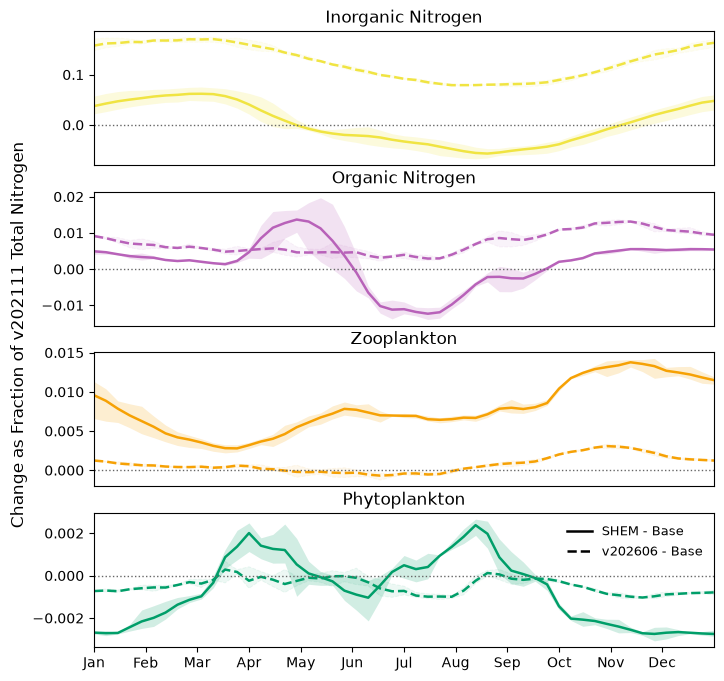

In [11]:
fig,axs = plt.subplots(4,1,figsize=(8,8),sharex=True)
colors = {'IN': '#F0E442', 'Phy': "#009E69", 'ON': "#B862B9", 'Zoo': "#F6A104",'Total':'#000000','HBac':"#E956C4"}
name_columns = {'IN':'Inorganic Nitrogen', 'Phy':'Phytoplankton', 'ON':'Organic Nitrogen', 'Zoo':'Zooplankton','Total':'Total','HBac':'Heterotrophic Bacteria'}
columns = ['IN', 'ON', 'Zoo', 'Phy']

for i, column in enumerate(columns):
    color = colors[column]

    # SHEM
    axs[i].fill_between(mean1.index,low1[column],high1[column],color=color,alpha=0.18,linewidth=0)
    axs[i].plot(mean1.index,mean1[column],color=color,linestyle='-',linewidth=1.8)

    # v202410
    axs[i].fill_between(mean2.index,low2[column],high2[column],color=color,alpha=0.07,edgecolor=color,linestyle='--',linewidth=0.7)
    axs[i].plot(mean2.index,mean2[column],color=color,linestyle='--',linewidth=1.8)

    axs[i].axhline(0,color='0.4',linestyle=':',linewidth=1)
    axs[i].set_title(name_columns[column])

for ax in axs:
    ax.set_xlim(1, 53)
    ax.set_xticks(month_weeks)

for ax in axs[:-1]:
    ax.tick_params(axis='x', bottom=False, labelbottom=False)


axs[-1].set_xticklabels(month_labels)

from matplotlib.lines import Line2D

style_legend = [
    Line2D([0], [0],color='black',linestyle='-',linewidth=1.8,label='SHEM - Base'),
    Line2D([0], [0],color='black',linestyle='--',linewidth=1.8,label='v202606 - Base')
]

axs[3].legend(handles=style_legend,loc='upper right',frameon=False,fontsize=9)

fig.supylabel('Change as Fraction of v202111 Total Nitrogen')

In [12]:
fig.savefig('budget_weekly.pdf',bbox_inches='tight')